# Practical 5: Extending the Shallow-Ice model

Anna Chen (yc4406)

## Abstract

This practical explores sensitivities of parameters inputted into a Shallow Ice-Sheet (SIA) model. The SIA model assumes accumulation via the Surface Mass Balance (SMB) parameter on the ice sheet surface and decrease in thickness via gravity as accumulation becomes large, following Glen's Flow Law. Crucial assumptions of the model include a no-flow boundary condition on the right hand side and a flat bed topography. The SIA model can be perturbed by changing two parameters: the Glen's Flow Law parameter $A$, and the equilibrium line position, which relates to seasonal changes in the SMB ($b$). First, by changing $A$, we found that a smaller $A$ yields a larger final ice thickness at every location $x$, including the ice divide ($x=0$), which qualitatively represent a more rigid ice sheet. However, changing $A$ does not significantly affect the final ice flux, $q$, as even the largest difference between two tested $A$ values yield only 50 $m^2/s$ difference in the final ice flux. Second, by setting the equilibrium line position variability as a cosine function of time, we tested the changes in SMB (which is a function of equilibrium line position at every location $x$) using different periods (50, 100, 200, and 400 years), simulating glacial-interglacial climate variability. We found that, when changing the period, the ice sheet height at the ice divide evolved about the same principle axis as if the SMB was not seasonally perturbed. But, it is clear that a shorter period makes smaller wiggles about the principle axis, whereas a longer period results in greater deviation from the seasonally-uniform ice growth. There is no significant difference on the shape of the final ice-sheet thickness profile, which shows that the final ice-sheet thickness when equilibrium conditions are met is determined by the Glen's Flow Law and its parameters (i.e. $A$), not the surface mass balance $b$. Overall, a shorter period yields higher frequency of a spiraling movement in the phase-time plot of ice thickness versus equilibrium line position, and a longer period vice versa. This shows that, when the time horizon is long enough, ice sheet under different climate variability conditions (i.e. periods) will eventually evolve towards the same equilibrium condition. However, the frequency of equilibrium line position shifting is indensified with shorter periods (i.e. more variable climatic conditions). This potentially suggests that higher and more frequent climatic variability can lead to greater disturbance and uncertainty in ice sheet evolution and stability.

## 0. The model

The ice-sheet model we have derived is defined by

$$
\frac{\partial H}{\partial t} = \dot{b_i}(x) - \frac{\partial q}{\partial x},
$$

$$
q = -\frac{2A}{n+2} \left(\rho g \alpha \right)^n  H^{n+2}  
$$

where $\dot{b_i}$ is the ice-equivalent rate of accumulation on the ice sheet surface, $x$ is the horizontal coordinate, $H$ is the ice thickness, $t$ is time, $q$ is the depth-intergrated flux per unit width (hereafter, flux), $A$ is the flow parameter from the flow law, $n$ is the exponent from the flow law, $\rho$ is the density of ice, $g$ is acceleration due to gravity, and $\alpha$ is the surface slope $\left(= - \frac{\partial H}{\partial x}\right)$.

We will use a a simple finite-difference scheme. It approximates the derivatives as differences, e.g.

$$
\frac{\partial H}{\partial t} = \frac{H^{j+1}-H^{j}}{\Delta t}
$$

where $j$ refers to which 'time step' we are looking at and $\Delta t$ is the time interval between timesteps. 

Applying this approximation (or more precisly a 'centered-difference version of the approximation) to the spatial derivatives gives

$$
\frac{\partial q}{\partial x}\bigg\rvert^j = \frac{ q^j_{i+1} - q^j_{i-1}}{2 \Delta x}
$$ 

and

$$
\frac{\partial H}{\partial x}\bigg\rvert^j = \frac{ H^j_{i+1} - H^j_{i-1}}{2 \Delta x}.
$$



Substituting these into our model gives

$$
\frac{H^{j+1}-H^{j}}{\delta t} = a_i - \frac{\partial q^j_{i+1} - q^j_{i-1}}{2 \Delta x},
$$


$$
q^j_i = -\frac{2A}{n+2} \left(\rho g  \right)^n  {H^j_i}^{n+2}  \left(\frac{H^j_{i+1} - H^j_{i-1}}{2\Delta x}\right)^n
$$


Note that although in class we defined $\alpha = - \frac{H^j_{i+1} - H^j_{i-1}}{2\Delta x}$, we change it to a positive sign because we only should have one negative sign in the total $q^j_i$ equation (and we already have it in the front), and also we've defined in Step 7's simulation that our spacestep is $\Delta x$, not $2\Delta x$.


We impose the surface mass balance (SMB) as a simple linear function of distance:

$$
a = 10^{-4}\left(\frac{X}{3}-x\right), 
$$

where $X$ is the length of the spatial domain. (We will change the SMB in part 2!)

We will also impose a no-flow boundary condition on the right hand side. 

We will also assume a flat bed topography.

## 1. Sensitivity to model parameters
- make your code into a function so it can easily be called while varying A and recording some metric of the ice sheet once it is steady state. 

- write a simple script to call the function many times with different physical parameters and plot the metric as a fn. of A (with A along the horizontal axis). 

In [ ]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

In [18]:
def shallow_ice(A = 24*10**(-25) * 365*24*60*60, 
                X = 40000, 
                dx = 200,
                T = 6000, 
                dt = 0.004,
                e = 0.0001,
                print_true=False,
                print_period = 80000,
                plot_true=False):
    """ Shallow-ice model with variable parameters, including the flow law parameter A.
    Does not print progress of simulation nor plots by default.

    Parameters:
    -----------------
        A: float
            Flow Law Parameter units [Pa a]
            Original value from Cuffey and Paterson 24e-25, units [Pa s]
        
        X: float
            Maximum length of size the model units [m]
        
        dx: float
            Size of each space step [m]
        
        T: float
            Maximum length of time the model is allowed to run, units [year]
        
        dt: float
            Size of each time step [year]

        e: float
            Parameter used to prevent ice thickness from reaching zero
        
        print_true: boolean
            Boolean parameter used to decide whether to report progress of simulation
        
        print_period: float
            When the time reaches a multiple of this number, the progress will be printed
        
        plot_true: boolean
            Boolean parameter used to decide whether to print plots
    
    Returns:
    ----------
        H: 2D numpy array
            2D array with rows being time (Lt) and columns being space (Lx)
        
        x: 1D numpy array
            1D array of space grids
        
        q: 2D numpy array
            2D array with rows being time (Lt) and columns being 1 less than full space grid (Lx-1)
        
        plots if plot_true

    """
    # Space Grid
    x = np.linspace(0,X,round(X/dx))    # Space array
    Lx = x.size                         # Length of the space array

    # Time Grid
    t = np.linspace(0,T,round(T/dt))    # Time array
    Lt = t.size                         # Length of the time array

    # Set up staggered space array
    x_stag = x[0:-1] + dx * 0.5         # Each point in x_stag is the average of the x value before and after it
    Lx_stag = x_stag.size

    # Set up parameters
    n = 3.0                              # The flow law exponent
    rho = 917                            # ice density,  units [kg/m^3]
    g = 10                               # acceleration due to gravity, units [m/s^2]

    # Preallocate the ice thickness array
    H = np.zeros((Lt, Lx))
    H[0, :] = e

    # Define surface mass balance b
    b = lambda x: 10**-4 * (X / 3 - x)       # Recall X is the max spatial length of 40000 m
    b_array = np.asarray(b(x))

    # pre-define flux and coefficients used for flux function
    q = np.zeros((Lt, Lx-1))
    q_coeff = -2.0 * A / (n + 2.0) * (rho * g) ** n

    for timestep in np.arange(1, Lt):
        # only print a message when the remainder of the timestep number and `print_period` is zero.
        if print_true:
            if timestep % print_period == 0:
                print(f'{t[timestep]:.1f} out of {T} years')

        # save the old thickness vector
        H_old = H[timestep - 1, :]

        # (1) compute H on the staggered grid (average of neighboring normal-grid H values)
        H_stag = 0.5 * (H_old[1:] + H_old[:-1])

        # (2) compute the surface slope on the staggered grid
        alpha = (H_old[1:] - H_old[:-1]) / dx

        # (3) compute the flux on the staggered grid
        q[timestep, :] = q_coeff * H_stag ** (n + 2.0) * (alpha ** n)

        # (4) compute the ice thickness at the current time step
        dqdx = (q[timestep, 1:] - q[timestep, :-1]) / dx

        H[timestep, 1:-1] = np.maximum(e, H_old[1:-1] + dt * (b_array[1:-1] - dqdx))

        # enforce minimum thickness and boundary conditions
        H[timestep, 0] = H[timestep, 1]
        H[timestep, -1] = e
    
    if plot_true:
        # Plot results
        fig = plt.figure(figsize=(16,8))

        axes = fig.add_subplot(4,1,1)
        axes.plt(x, H[-1, :], 'g-')
        axes.set_xlabel('distance, $x$ [m]')
        axes.set_ylabel('final ice thickness, $H(x,T)$')
        axes.set_title('Final Ice Thickness H(-1, :)')

        axes = fig.add_subplot(4,1,2)
        axes.plt(x, np.transpose(H[0:-1:10000, :]))
        axes.set_xlabel(r'distance, $x$ [m]')
        axes.set_ylabel(r'ice thickness, $H(x,T)$')
        axes.set_title('Ice Thickness at each 10,000th time step')

        axes = fig.add_subplot(4,1,3)
        axes.plt(t, H[:, 0], 'g-')
        axes.set_xlabel(r'time, $t$ [years]')
        axes.set_ylabel('ice thickness [m]')
        axes.set_title('Ice Thickness at the left of the domain, $H(x=0,t)$')

        axes = fig.add_subplot(4,1,4)
        axes.plt(x[0:-1], q[-1, :], 'g-')
        axes.set_xlabel('Distance, $x$ [m]')
        axes.set_ylabel('Ice flux, $q(x,T)$ [m^2/s]')
        axes.set_title('Final Ice Flux, $q(x,T=-1)$')

        plt.show()
    
    return H, x, q

In [ ]:
# Set up some A that we want to try out
# A represents how soft the ice is
A_vectors = np.linspace(1,26,5)*10**(-25) * 365*24*60*60
left_final = []
H_final = []
q_final = []

for A in A_vectors:
    print(f"A = {A}")
    H, x, q = shallow_ice(A = A,          # Uses A from A_vectors
                          dt = 0.01)      # Make the model run faster by reducing time step size
    left_final.append(H[-1,0])            # This list gathers the final height at the ice divide (leftmost domain)
    H_final.append(H[-1,:])               # This list gathers the final height of the entire space domain
    q_final.append(q[-1,:])               # This list gathers the final ice flux of the entire space domain

A = 3.1536e-18
A = 2.2863600000000002e-17
A = 4.25736e-17
A = 6.228360000000002e-17
A = 8.199360000000001e-17


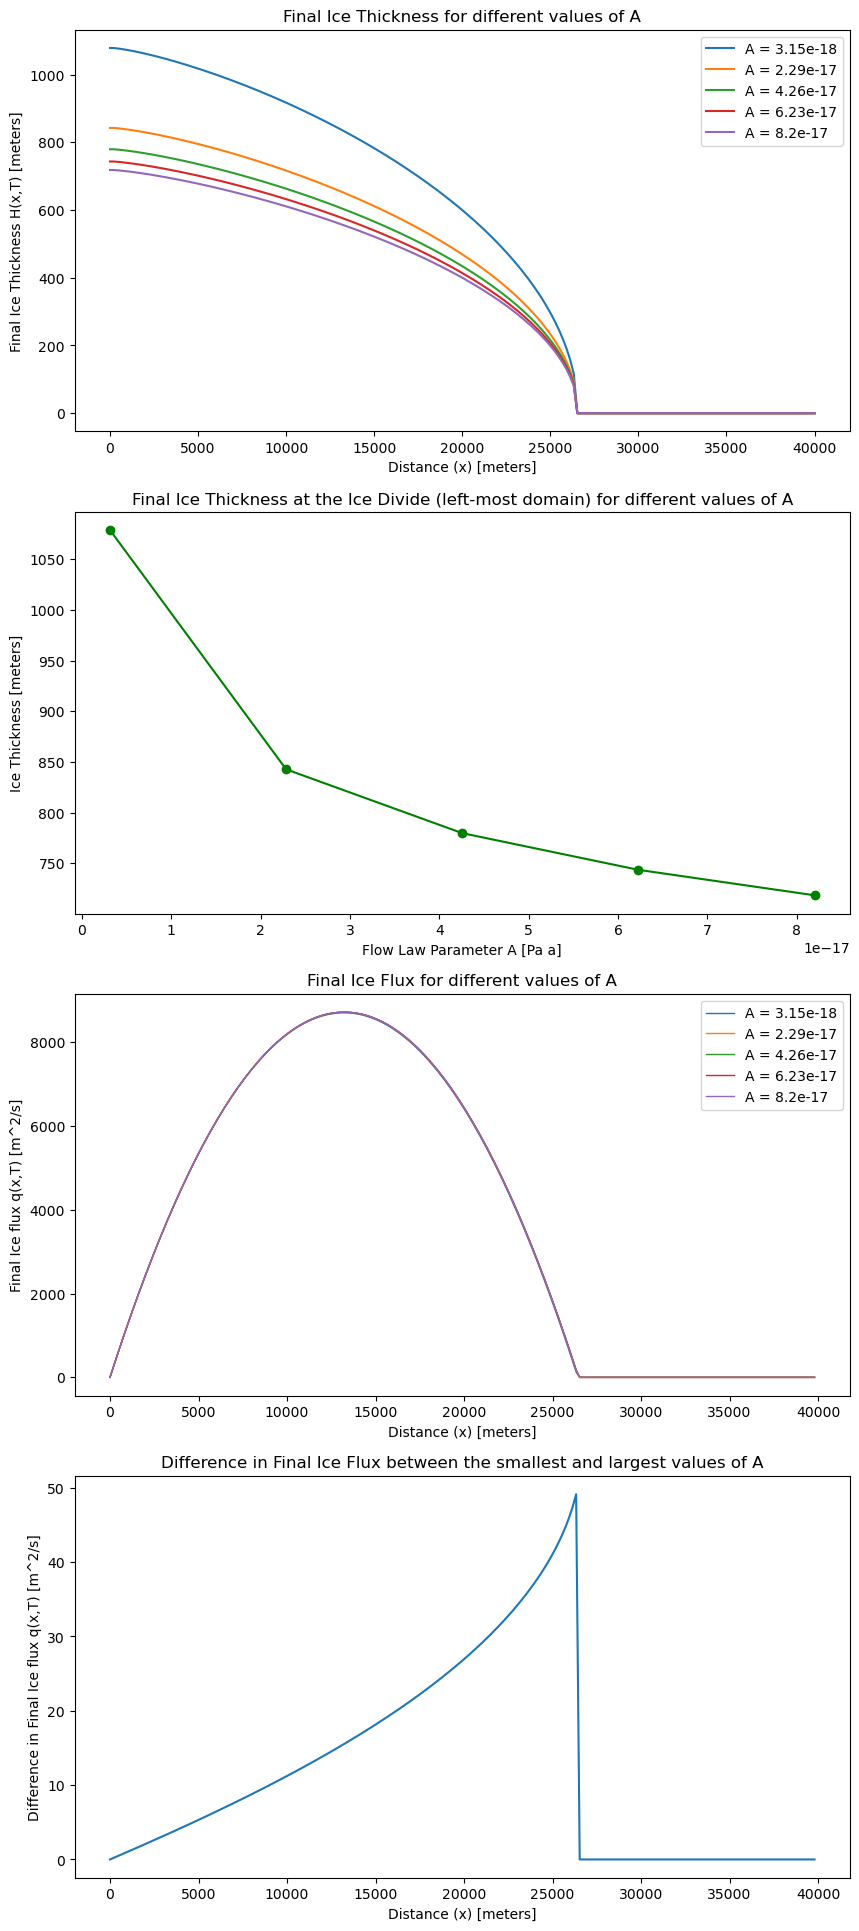

In [ ]:
# To make the difference between final ice flux metrics clearer, compute the difference between results from different A values
q_diff = q_final[-1] - q_final[0]

# Plot all figures
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 24))

for i in range(1,6):
    ax1.plot(x, np.array(H_final[i-1]).T, label = f'A = {A_vectors[i-1]:.3g}')
ax1.set_xlabel('Distance (x) [meters]')
ax1.set_ylabel('Final Ice Thickness H(x,T) [meters]')
ax1.set_title('Final Ice Thickness for different values of A')
ax1.legend()

ax2.plot(A_vectors, left_final, 'go-')
ax2.set_xlabel('Flow Law Parameter A [Pa a]')
ax2.set_ylabel('Ice Thickness [meters]')
ax2.set_title('Final Ice Thickness at the Ice Divide (left-most domain) for different values of A')

for i in range(1,6):
    ax3.plot(x[0:-1], np.array(q_final[i-1]).T, linewidth = 1, label = f'A = {A_vectors[i-1]:.3g}')
ax3.set_xlabel('Distance (x) [meters]')
ax3.set_ylabel('Final Ice flux q(x,T) [m^2/s]')
ax3.set_title('Final Ice Flux for different values of A')
ax3.legend()

ax4.plot(x[0:-1], np.array(q_diff).T)
ax4.set_xlabel('Distance (x) [meters]')
ax4.set_ylabel('Difference in Final Ice flux q(x,T) [m^2/s]')
ax4.set_title('Difference in Final Ice Flux between the smallest and largest values of A')

plt.show()

## 2. Transience
- write a new function which runs the model with a sinusoidally-varying equilibrium line position. 
    
- plot a time-varying metric (e.g. ice thickness at some location) against time. 

- plot this metric against equilibrium line position as both vary throughout a model run. (this is a phase-space plot).

- examine how the shape of the phase-space plot changes as you vary the period of the 	sinusoidal variation in equilibrium line position.

In [13]:
def shallow_ice_transient(A = 24*10**(-25) * 365*24*60*60, 
                         X = 40000, 
                         dx = 200,
                         T = 3000, 
                         dt = 0.004,
                         e = 0.0001,
                         elx = 1/3,
                         period = 100,  # Period of ELX oscillation in years
                         amplitude = 0.2,  # Fractional amplitude of ELX oscillation
                         print_true=False,
                         print_period = 80000):
    """Shallow-ice model with sinusoidally varying equilibrium line position.
    
    The surface mass balance (SMB) varies as the equilibrium line position oscillates:
    SMB = b0 * (X * elx * (1 + A*cos(2πt/P)) - x)
    where:
    - b0 is the base mass balance rate
    - elx is the mean equilibrium line position (as fraction of X)
    - A is the amplitude of oscillation
    - P is the period of oscillation
    - x is the distance along the domain
    
    Parameters:
    -----------
    A : float
        Flow law parameter [Pa^(-n) year^(-1)]
    X : float
        Domain length [m]
    dx : float
        Spatial step [m]
    T : float
        Total simulation time [years]
    dt : float
        Time step [years]
    e : float
        Minimum ice thickness [m]
    elx : float
        Mean equilibrium line position as fraction of X
    period : float
        Period of ELX oscillation [years]
    amplitude : float
        Amplitude of ELX oscillation as fraction of mean
    print_true : bool
        Whether to print progress
    print_period : int
        How often to print progress
        
    Returns:
    --------
    H : ndarray
        Ice thickness [m] at each time and position
    x : ndarray
        Distance along domain [m]
    t : ndarray
        Time points [years]
    elx_history : ndarray
        Equilibrium line position [m] at each time
    """
    # Space grid
    x = np.linspace(0, X, round(X/dx))    
    Lx = x.size                         
    x_stag = x[0:-1] + dx * 0.5        
    Lx_stag = x_stag.size

    # Time grid
    t = np.linspace(0, T, round(T/dt))    
    Lt = t.size                         

    # Physical parameters
    n = 3.0                             
    rho = 917                           
    g = 10                              
    
    # Initialize arrays
    H = np.zeros((Lt, Lx))
    H[0, :] = e
    q = np.zeros((Lt, Lx-1))
    elx_history = np.zeros(Lt)
    
    # Constants for flux and SMB calculations
    q_coeff = -2.0 * A / (n + 2.0) * (rho * g) ** n
    b0 = 10**-4  # Base SMB rate [m/year]

    for timestep in range(1, Lt):
        # Print progress if requested
        if print_true and timestep % print_period == 0:
            print(f'{t[timestep]:.1f} out of {T} years')
            
        # Calculate current equilibrium line position
        current_elx = X * elx * (1 + amplitude * np.cos(2 * np.pi * t[timestep] / period))
        elx_history[timestep] = current_elx
        
        # Calculate surface mass balance
        b = lambda x: b0 * (current_elx - x)
        b_array = np.asarray(b(x))
        
        # Save previous timestep
        H_old = H[timestep - 1, :]
        
        # Calculate on staggered grid
        H_stag = 0.5 * (H_old[1:] + H_old[:-1])
        alpha = (H_old[1:] - H_old[:-1]) / dx
        
        # Calculate flux
        q[timestep, :] = q_coeff * H_stag**(n + 2.0) * alpha**n
        
        # Update thickness
        dqdx = (q[timestep, 1:] - q[timestep, :-1]) / dx
        H[timestep, 1:-1] = np.maximum(e, H_old[1:-1] + dt * (b_array[1:-1] - dqdx))
        
        # Boundary conditions
        H[timestep, 0] = H[timestep, 1]  # No-flux at divide
        H[timestep, -1] = e              # Zero thickness at margin
    
    return H, x, t, elx_history

In [14]:
# Test the transient model with different periods
periods = [50, 100, 200, 400]  # Different periods to test
results = []

for p in periods:
    print(f"Running simulation with period = {p} years")
    H, x, t, elx = shallow_ice_transient(period=p, T=2000)
    results.append((H, elx))

Running simulation with period = 50 years
Running simulation with period = 100 years
Running simulation with period = 200 years
Running simulation with period = 400 years


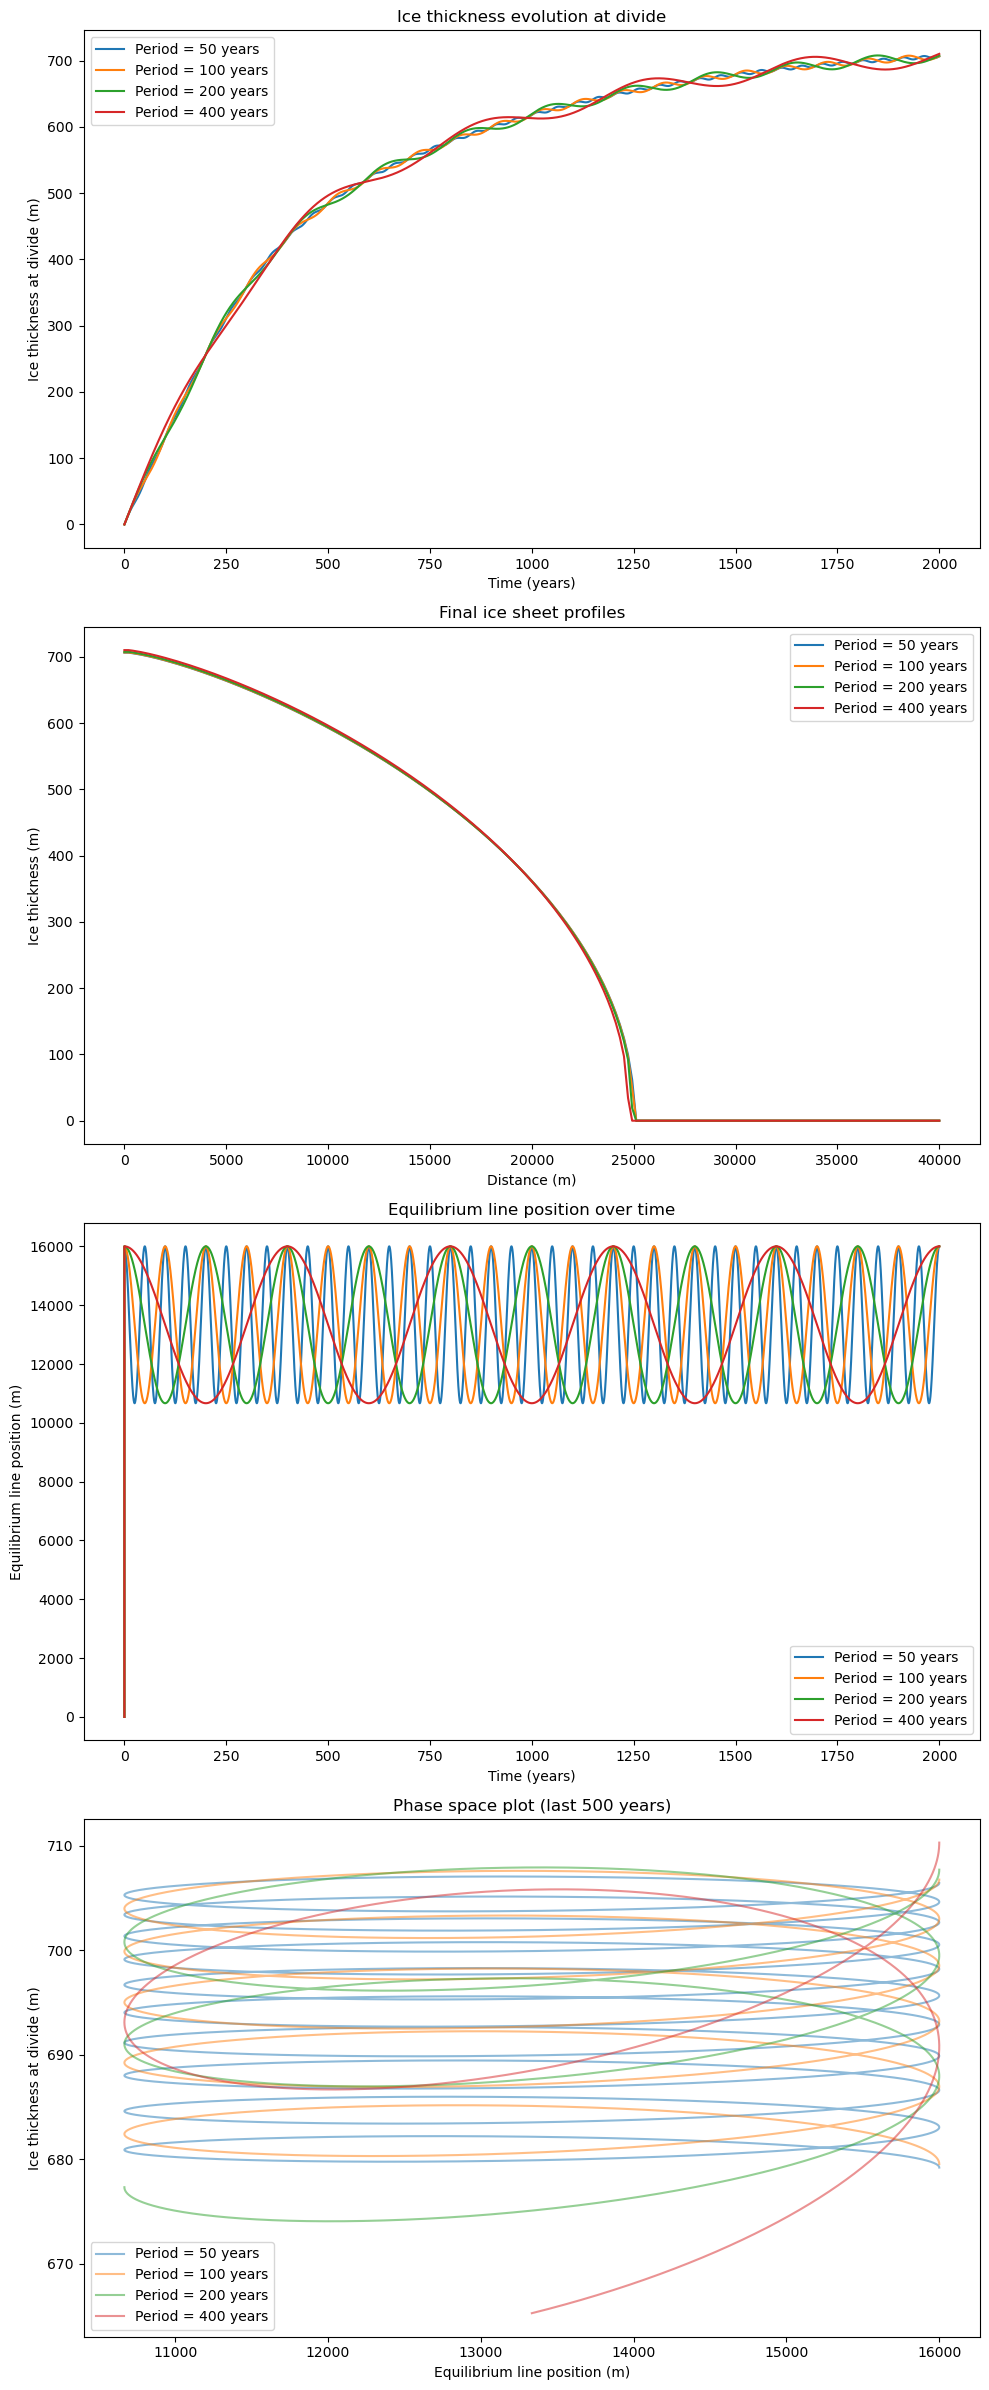

In [ ]:
# Create plots
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 24))

# 1. Plot ice thickness at divide vs time for different periods
for i, p in enumerate(periods):
    H, elx = results[i]
    ax1.plot(t, H[:, 0], label=f'Period = {p} years')
ax1.set_xlabel('Time (years)')
ax1.set_ylabel('Ice thickness at divide (m)')
ax1.set_title('Ice thickness evolution at divide')
ax1.legend()

# 2. Plot final ice sheet profiles
for i, p in enumerate(periods):
    H, elx = results[i]
    ax2.plot(x, H[-1, :], label=f'Period = {p} years')
ax2.set_xlabel('Distance (m)')
ax2.set_ylabel('Ice thickness (m)')
ax2.set_title('Final ice sheet profiles')
ax2.legend()

# 3. Plot equilibrium line position vs time
for i, p in enumerate(periods):
    H, elx = results[i]
    ax3.plot(t, elx, label=f'Period = {p} years')
ax3.set_xlabel('Time (years)')
ax3.set_ylabel('Equilibrium line position (m)')
ax3.set_title('Equilibrium line position over time')
ax3.legend()

# 4. Phase space plot (last 500 years)
start_idx = int(len(t) - 500/0.004)  # Index for last 500 years
for i, p in enumerate(periods):
    H, elx = results[i]
    ax4.plot(elx[start_idx:], H[start_idx:, 0], 
             label=f'Period = {p} years', alpha=0.5)
ax4.set_xlabel('Equilibrium line position (m)')
ax4.set_ylabel('Ice thickness at divide (m)')
ax4.set_title('Phase space plot (last 500 years)')
ax4.legend()

plt.show()

**Notes from class/talking with Jonny:**

At every time step, use a different SMB array (different b). Calculate the b based on temporal variability.

How we previously defined the SMB array (b):

`
b = lambda x: 10**-4 * (X / 3 - x)
`

`
b_array = np.asarray(b(x))
`

Where X is the max spatial length of 40000 m.

Define new climate variability as a sin function to simulate climate changes. Eg. define X/3 as a function of time

`
b(x) = b0 * (X*elx*(1 + elx_variability(timestep))-x)
`

`
elx_variability = amplitude * np.cos(2 * np.pi * t / period)
`

And see how elx changes up and down throughout time.